In [ ]:
# Importing Libraties
import os, json, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [ ]:
# Load the photos JSON file
photos = pd.read_json("./Yelp_Photos/photos.json", lines=True)
# Load the business JSON file
businesses = pd.read_json("./Yelp_Json/yelp_academic_dataset_business.json", lines=True)


In [ ]:
# Encode labels
label_to_index = {label: idx for idx, label in enumerate(photos['label'].unique())}
photos['label_idx'] = photos['label'].map(label_to_index)


In [ ]:
# Select small sample for quick training
photos = photos.groupby('label_idx').head(100)

In [ ]:
# Image paths
IMG_DIR = './Yelp_Photos/yelp_photos/photos'
IMG_SIZE = 224
images, y = [], []

In [ ]:
for i, row in photos.iterrows():
    path = os.path.join(IMG_DIR, f"{row['photo_id']}.jpg")
    if os.path.exists(path):
        img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img)
        img = preprocess_input(img)
        images.append(img)
        y.append(row['label_idx'])


In [ ]:
# Final data arrays
X = np.array(images)
y = to_categorical(np.array(y))

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [ ]:
# Step 5: Define trainable VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True

In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [ ]:
# Step 6: Callbacks for saving and early stopping
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [ ]:
# Step 7: Train model
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Total training time: {end - start:.2f} seconds")

Epoch 1/10


13/13 - 110s - 8s/step - accuracy: 0.1750 - auc: 0.4763 - loss: 10.7712 - val_accuracy: 0.2000 - val_auc: 0.5044 - val_loss: 1.8233
Epoch 2/10


13/13 - 112s - 9s/step - accuracy: 0.2050 - auc: 0.4817 - loss: 1.6292 - val_accuracy: 0.2600 - val_auc: 0.5226 - val_loss: 1.6090
Epoch 3/10
13/13 - 114s - 9s/step - accuracy: 0.2125 - auc: 0.5107 - loss: 1.6098 - val_accuracy: 0.2000 - val_auc: 0.4938 - val_loss: 1.6096
Epoch 4/10
13/13 - 116s - 9s/step - accuracy: 0.1850 - auc: 0.5011 - loss: 1.6959 - val_accuracy: 0.2000 - val_auc: 0.5000 - val_loss: 1.6095
Epoch 5/10
13/13 - 115s - 9s/step - accuracy: 0.2025 - auc: 0.5134 - loss: 1.6218 - val_accuracy: 0.2200 - val_auc: 0.5196 - val_loss: 1.6095

🕒 Total training time: 567.74 seconds


In [ ]:
# Evaluate best model
model = load_model('best_vgg16_model.h5')
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n✅ Validation Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")


✅ Validation Accuracy: 0.2600, AUC: 0.5226


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step


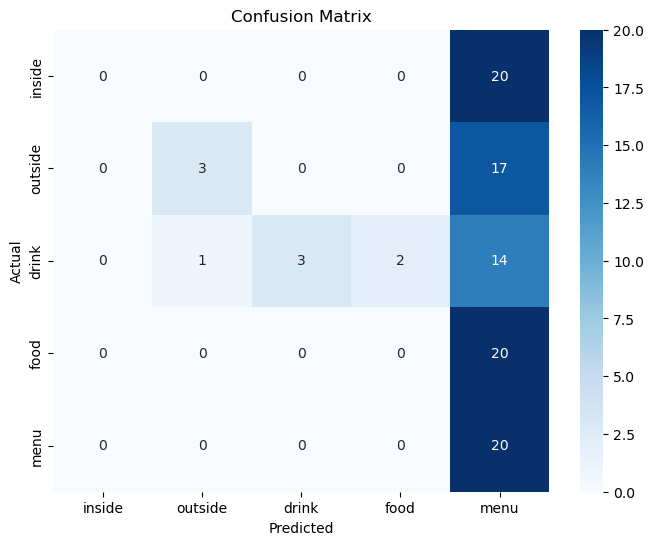


📊 Classification Report:
              precision    recall  f1-score   support

      inside       0.00      0.00      0.00        20
     outside       0.75      0.15      0.25        20
       drink       1.00      0.15      0.26        20
        food       0.00      0.00      0.00        20
        menu       0.22      1.00      0.36        20

    accuracy                           0.26       100
   macro avg       0.39      0.26      0.17       100
weighted avg       0.39      0.26      0.17       100



C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Confusion matrix and report
y_pred = model.predict(X_val)
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_to_index.keys(), yticklabels=label_to_index.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_to_index.keys()))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

C:\Users\saura\AppData\Local\Temp\ipykernel_21776\2895059950.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors
C:\Users\saura\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


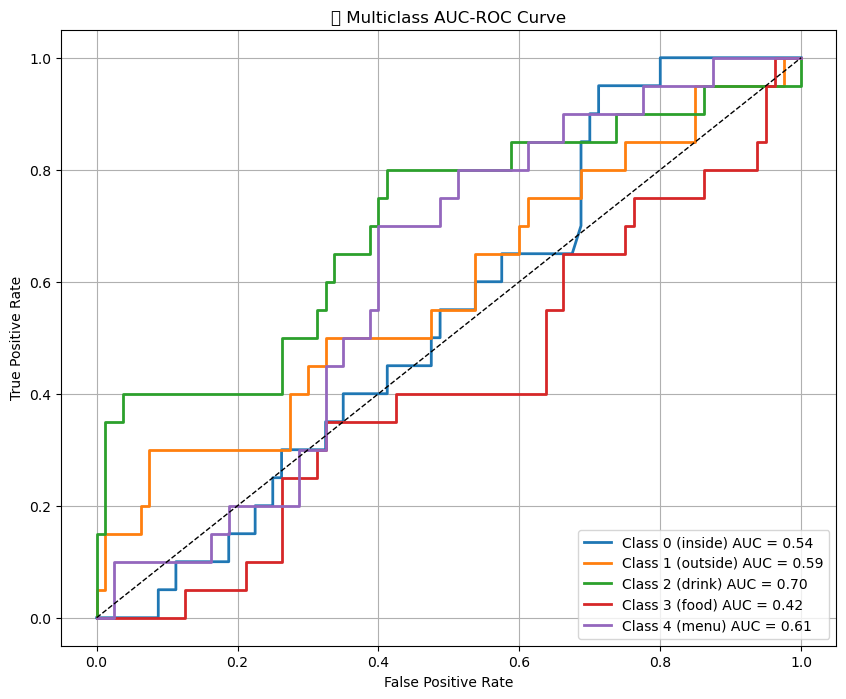

In [ ]:
#  Plot AUC Curve
fpr = {}
tpr = {}
roc_auc = {}
n_classes = y.shape[1]
y_val_bin = label_binarize(np.argmax(y_val, axis=1), classes=range(n_classes))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10').colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Class {i} ({list(label_to_index.keys())[i]}) AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("📈 Multiclass AUC-ROC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Tunning for the first time

In [ ]:
#Tunning

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
# Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [ ]:
# VGG16 Model (lighter + regularized)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

optimizer = Adam(learning_rate=1e-4)  # Slower learning rate

model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


In [ ]:
# Callbacks
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)


In [ ]:
#  Train (with augmentation)
start = time.time()
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Training time: {end - start:.2f} seconds")

C:\Users\saura\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


13/13 - 111s - 9s/step - accuracy: 0.2025 - auc: 0.5166 - loss: 2.3087 - val_accuracy: 0.2000 - val_auc: 0.5426 - val_loss: 1.6038
Epoch 2/15


13/13 - 114s - 9s/step - accuracy: 0.2125 - auc: 0.5344 - loss: 1.6113 - val_accuracy: 0.2900 - val_auc: 0.5925 - val_loss: 1.5903
Epoch 3/15
13/13 - 115s - 9s/step - accuracy: 0.2300 - auc: 0.5256 - loss: 1.6105 - val_accuracy: 0.2300 - val_auc: 0.5340 - val_loss: 1.6061
Epoch 4/15
13/13 - 114s - 9s/step - accuracy: 0.1900 - auc: 0.5139 - loss: 1.6082 - val_accuracy: 0.2200 - val_auc: 0.5365 - val_loss: 1.6068
Epoch 5/15
13/13 - 115s - 9s/step - accuracy: 0.1950 - auc: 0.4954 - loss: 1.6099 - val_accuracy: 0.2800 - val_auc: 0.5592 - val_loss: 1.6063
Epoch 6/15
13/13 - 115s - 9s/step - accuracy: 0.2175 - auc: 0.5222 - loss: 1.6083 - val_accuracy: 0.2700 - val_auc: 0.6208 - val_loss: 1.6032

🕒 Training time: 685.70 seconds


In [ ]:
#It is still underfitting. Now using a dense layer and using a lower learning rate

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reload base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Model with higher capacity
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),  # Less aggressive
    Dense(512, activation='relu', kernel_regularizer=l2(0.0005)),  # Lighter L2
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

In [ ]:
# Compile with slower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks
checkpoint_cb = ModelCheckpoint("best_vgg16_model.h5", save_best_only=True, monitor='val_loss')
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)


In [ ]:
# Training
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,  # Back to 32
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb, earlystop_cb, lr_reduce_cb],
    verbose=2
)
end = time.time()
print(f"\n🕒 Training time: {end - start:.2f} seconds")


Epoch 1/5


13/13 - 186s - 14s/step - accuracy: 0.3050 - auc: 0.6011 - loss: 2.7756 - val_accuracy: 0.4800 - val_auc: 0.7608 - val_loss: 1.5941 - learning_rate: 1.0000e-04
Epoch 2/5


13/13 - 166s - 13s/step - accuracy: 0.4325 - auc: 0.7278 - loss: 1.6003 - val_accuracy: 0.5300 - val_auc: 0.8299 - val_loss: 1.3813 - learning_rate: 1.0000e-04
Epoch 3/5
13/13 - 167s - 13s/step - accuracy: 0.4250 - auc: 0.7325 - loss: 1.6082 - val_accuracy: 0.4000 - val_auc: 0.7451 - val_loss: 1.5671 - learning_rate: 1.0000e-04
Epoch 4/5


13/13 - 166s - 13s/step - accuracy: 0.4875 - auc: 0.7765 - loss: 1.5218 - val_accuracy: 0.5900 - val_auc: 0.8749 - val_loss: 1.3601 - learning_rate: 1.0000e-04
Epoch 5/5


13/13 - 167s - 13s/step - accuracy: 0.5350 - auc: 0.8249 - loss: 1.4433 - val_accuracy: 0.5600 - val_auc: 0.8590 - val_loss: 1.3337 - learning_rate: 1.0000e-04

🕒 Training time: 851.28 seconds


C:\Users\saura\AppData\Local\Temp\ipykernel_21776\2895059950.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors
C:\Users\saura\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


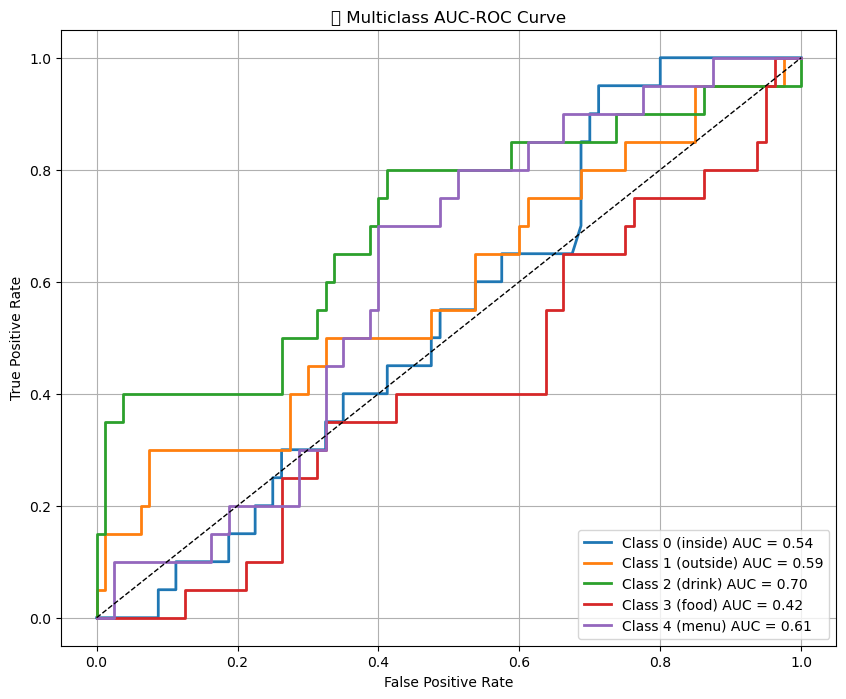

In [ ]:
#  Plot AUC Curve
fpr = {}
tpr = {}
roc_auc = {}
n_classes = y.shape[1]
y_val_bin = label_binarize(np.argmax(y_val, axis=1), classes=range(n_classes))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10').colors
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Class {i} ({list(label_to_index.keys())[i]}) AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("📈 Multiclass AUC-ROC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


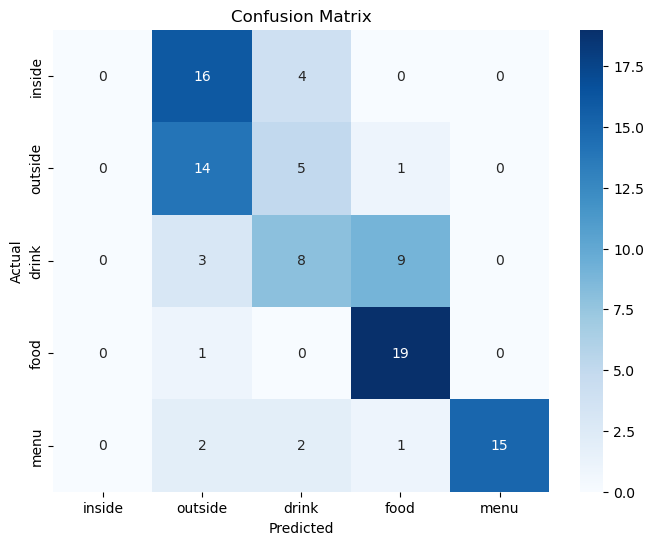


📊 Classification Report:
              precision    recall  f1-score   support

      inside       0.00      0.00      0.00        20
     outside       0.39      0.70      0.50        20
       drink       0.42      0.40      0.41        20
        food       0.63      0.95      0.76        20
        menu       1.00      0.75      0.86        20

    accuracy                           0.56       100
   macro avg       0.49      0.56      0.51       100
weighted avg       0.49      0.56      0.51       100



C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\saura\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Confusion matrix and report
y_pred = model.predict(X_val)
y_true = np.argmax(y_val, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_to_index.keys(), yticklabels=label_to_index.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=label_to_index.keys()))

#Summary

While running the model for the first time the accuracy was training accuray was 20 and validatin accuracy was 26 which went on underfitting. We tuned with slower learning rete and dropout to 0.5, the model was still underfitting. At last we dropped the dropout to 0.3, the model was good with training accuracy of 0.53, testing accuracy of 0.56 and AUC of 0.82